# **Experiment 4 Notebook**



---
## Setup Environment

In [2]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



You can now save your data files in: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [3]:
student_name = "Aryan Goel"
student_id = "26040826"

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# No extra packages required.

### 0.b Import Packages

In [7]:
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)

sns.set(style="whitegrid")
alt.data_transformers.disable_max_rows()
RANDOM_STATE = 42

---
## A. Experiment Description

In [8]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "4"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [9]:
experiment_hypothesis = """
Hypothesis:
A calibrated stacking ensemble (combining RandomForest, HistGradientBoosting, and LogisticRegression with a calibrated meta-decision layer) will deliver the strongest overall model for multiclass vitamin-deficiency diagnosis by improving class-balanced performance and decision reliability compared with prior single-model and uncalibrated approaches.

Question to answer:
Can model fusion plus probability calibration outperform the current champion (Experiment 2/3 benchmark) on macro-F1 and balanced accuracy while also providing more trustworthy probabilities for downstream business decisions?

Why this is worthwhile:
1) Experiments 1 and 2 showed that different model families capture different signal patterns; Experiment 3 suggested ensemble fusion can reduce complementary errors.
2) In this project, business value depends on balanced class quality (not just headline accuracy), so reducing minority-class blind spots is critical.
3) Even with good classification scores, poor probability quality can lead to weak threshold decisions in deployment; calibration directly addresses this risk.
4) Experiment 4 is therefore the right final step to test deployment readiness: discrimination quality + operational decision confidence.
"""

In [10]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [11]:
experiment_expectations = """
Expected outcome:
- Maintain or improve macro-F1 and balanced accuracy vs Exp2/Exp3.
- Improve probability quality for safer threshold-based decisions.

Scenarios:
1) Confirmed: Exp4 wins on >=2 of (macro_f1, balanced_accuracy, accuracy) vs current champion.
2) Partially confirmed: similar discrimination but better decision reliability.
3) Rejected: no gain; keep simpler champion from earlier experiments.
4) Unexpected: significant gain in one metric but loss in another, prompting deeper analysis of error patterns and calibration effects.
"""

In [12]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [13]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

---
## D. Feature Selection


In [14]:
# D
if isinstance(y_train, pd.DataFrame): y_train = y_train.iloc[:, 0]
if isinstance(y_val, pd.DataFrame): y_val = y_val.iloc[:, 0]
if isinstance(y_test, pd.DataFrame): y_test = y_test.iloc[:, 0]

features_list = X_train.columns.tolist()
print("Selected features:", len(features_list))
print(features_list[:10])

Selected features: 80
['age', 'postcode', 'bmi', 'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake', 'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake', 'calcium_intake']


In [15]:
feature_selection_explanations = """
All prepared features are retained to preserve comparability with Exp1–Exp3.
This isolates Experiment 4 effects to model strategy (stacking + calibration), not feature-space changes.
Given the moderate feature count and prior experiments' focus on model architecture, aggressive feature selection is deferred to avoid confounding factors.
This approach allows us to directly assess whether the ensemble strategy can extract more value from the same feature set, which is critical for understanding the true contribution of model fusion and calibration in this context.
"""

In [16]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation split integrity and missingness


In [17]:
# E.1
print("Shapes:", X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)
print("NaNs:", X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum())

Shapes: (3500, 80) (3500,) (750, 80) (750,) (750, 80) (750,)
NaNs: 0 0 0


In [18]:
data_transformation_1_explanations = """
Validated split integrity and missingness before training to prevent execution drift and preserve fair comparison.
The data is clean and ready for modeling, so no imputation or transformation is applied at this stage.
"""

In [19]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### E.2 Data Transformation : Numeric coercion + train-median


In [20]:
# E.2 Numeric coercion + train-median fill ensures sklearn compatibility and leakage-safe imputation.
# The data was already clean, so this step is a safeguard against any unexpected non-numeric values and ensures that all features are in a suitable format for modeling without introducing data leakage from the validation or test sets.
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_val = X_val.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

med = X_train.median()
X_train = X_train.fillna(med)
X_val = X_val.fillna(med)
X_test = X_test.fillna(med)

print("Post-fill NaNs:", X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum())

Post-fill NaNs: 0 0 0


In [21]:
data_transformation_2_explanations = """
Numeric coercion + train-median fill ensures sklearn compatibility and leakage-safe imputation.
The data was already clean, so this step is a safeguard against any unexpected non-numeric values and ensures that all features are in a suitable format for modeling without introducing data leakage from the validation or test sets.
"""

In [22]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### E.3 Data Transformation : Class distribution is stable across splits


In [23]:
# E.3
def class_dist(y): return (y.value_counts(normalize=True)*100).round(2).to_frame("percent")
display(class_dist(y_train)); display(class_dist(y_val)); display(class_dist(y_test))

,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.80
Rickets_Osteomalacia,24.69
Night_Blindness,4.89
Scurvy,3.23


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.80
Rickets_Osteomalacia,24.67
Night_Blindness,4.93
Scurvy,3.20


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.93
Rickets_Osteomalacia,24.67
Night_Blindness,4.80
Scurvy,3.20


In [24]:
data_transformation_3_explanations = """
Class distribution is stable across splits, supporting reliable macro-F1/balanced-accuracy interpretation.
No significant class imbalance shifts are observed, so performance differences can be attributed to model effects rather than data distribution changes.
"""

In [25]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

### G.n Fixing Alignment

> You can add more cells related to data preparation in this section

In [26]:
# G.n
print("Column alignment:", list(X_train.columns)==list(X_val.columns)==list(X_test.columns))

Column alignment: True


---
## F. Feature Engineering

### F.1 New Feature "biomarker_gap_d_b12_exp4"



In [27]:
# F.1
if {"serum_vitamin_d","serum_vitamin_b12"}.issubset(X_train.columns):
    X_train["biomarker_gap_d_b12_exp4"] = X_train["serum_vitamin_d"] - X_train["serum_vitamin_b12"]
    X_val["biomarker_gap_d_b12_exp4"] = X_val["serum_vitamin_d"] - X_val["serum_vitamin_b12"]
    X_test["biomarker_gap_d_b12_exp4"] = X_test["serum_vitamin_d"] - X_test["serum_vitamin_b12"]
else:
    X_train["biomarker_gap_d_b12_exp4"] = 0.0
    X_val["biomarker_gap_d_b12_exp4"] = 0.0
    X_test["biomarker_gap_d_b12_exp4"] = 0.0

In [28]:
feature_engineering_1_explanations = """
Captures relative biomarker imbalance, helping separation where absolute values overlap.
This engineered feature may reveal patterns of deficiency that are not apparent when considering each biomarker in isolation, potentially improving model discrimination for cases where the interaction between vitamin D and B12 levels is clinically relevant.
"""

In [29]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "symptom_to_intake_ratio_exp4"


In [30]:
# F.2
if {"symptoms_count","vitamin_d_intake"}.issubset(X_train.columns):
    X_train["symptom_to_intake_ratio_exp4"] = X_train["symptoms_count"]/(X_train["vitamin_d_intake"]+1e-6)
    X_val["symptom_to_intake_ratio_exp4"] = X_val["symptoms_count"]/(X_val["vitamin_d_intake"]+1e-6)
    X_test["symptom_to_intake_ratio_exp4"] = X_test["symptoms_count"]/(X_test["vitamin_d_intake"]+1e-6)
else:
    X_train["symptom_to_intake_ratio_exp4"] = 0.0
    X_val["symptom_to_intake_ratio_exp4"] = 0.0
    X_test["symptom_to_intake_ratio_exp4"] = 0.0

In [31]:
feature_engineering_2_explanations = """
Encodes unresolved symptom burden relative to intake support.
This feature may help identify cases where symptoms persist despite supplementation, which could indicate more complex deficiency patterns or non-compliance, thus providing additional signal for the model to differentiate between classes.
"""

In [32]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "bmi_symptom_interaction_exp4"


In [33]:
# F.3
if {"bmi","symptoms_count"}.issubset(X_train.columns):
    X_train["bmi_symptom_interaction_exp4"] = X_train["bmi"]*X_train["symptoms_count"]
    X_val["bmi_symptom_interaction_exp4"] = X_val["bmi"]*X_val["symptoms_count"]
    X_test["bmi_symptom_interaction_exp4"] = X_test["bmi"]*X_test["symptoms_count"]
else:
    X_train["bmi_symptom_interaction_exp4"] = 0.0
    X_val["bmi_symptom_interaction_exp4"] = 0.0
    X_test["bmi_symptom_interaction_exp4"] = 0.0

print("Final features:", X_train.shape[1])

Final features: 83


In [34]:
feature_engineering_3_explanations = """
Adds non-linear interaction signal between body profile and symptom burden.
This feature may capture complex relationships where the impact of symptoms on deficiency risk is modulated by BMI, potentially improving model performance for cases where this interaction is clinically relevant. For example, high symptom counts may indicate more severe deficiency in individuals with higher BMI, and this interaction could help the model better differentiate between classes in such cases. This engineered feature allows the model to learn patterns that are not simply additive, which could be crucial for improving discrimination in cases where the relationship between symptoms and deficiency risk is influenced by body composition. 
"""

In [35]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### F.n Fixing "Nan Values"

> You can add more cells related to new features in this section

In [36]:
# F.n - robust numeric + inf/nan handling after engineered features
for df_name in ["X_train", "X_val", "X_test"]:
    df = globals()[df_name]
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

# fill with train medians (leak-safe)
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# optional light clipping to stabilize engineered tails
eng_cols = [
    "biomarker_gap_d_b12_exp4",
    "symptom_to_intake_ratio_exp4",
    "bmi_symptom_interaction_exp4"
]
for c in eng_cols:
    if c in X_train.columns:
        q1, q99 = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
        X_train[c] = X_train[c].clip(q1, q99)
        X_val[c] = X_val[c].clip(q1, q99)
        X_test[c] = X_test[c].clip(q1, q99)

print("No inf/nan:",
      np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum(),
      X_train.isna().sum().sum())
print("Feature count:", X_train.shape[1])
print("Column alignment:", list(X_train.columns) == list(X_val.columns) == list(X_test.columns))

No inf/nan: 0 0
Feature count: 83
Column alignment: True


---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [37]:
# G.1
from sklearn.ensemble import StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
print("Using calibrated stacking ensemble.")

Using calibrated stacking ensemble.


In [38]:
algorithm_selection_explanations = """
Experiment 4 proceeds with stacking + calibration to combine complementary learners and improve probability reliability for operational decisions. This approach directly tests whether model fusion plus calibration can enhance both discrimination and decision confidence compared to the best single-model performance from Experiments 2/3, which is critical for deployment readiness in a business context where balanced class performance and trustworthy probabilities are essential.
Experiment 4 applies calibrated stacking as a deployment-readiness test: combine complementary learners, then improve probability reliability.
This moves evaluation from 'best classifier' to 'best decision-support system' by considering both discrimination and confidence quality.
The approach is appropriate where threshold-based business actions depend on trustworthy predicted probabilities.
"""

In [39]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [40]:
# G.2
stack_param_dist = {
    "final_estimator__C": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 20.0],
    "final_estimator__class_weight": [None, "balanced"],
    "final_estimator__solver": ["lbfgs"],
    "passthrough": [False, True]
}
stack_param_dist

{'final_estimator__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 20.0],
 'final_estimator__class_weight': [None, 'balanced'],
 'final_estimator__solver': ['lbfgs'],
 'passthrough': [False, True]}

In [41]:
hyperparameters_selection_explanations = """
Meta-learner regularization is tuned for class-balanced generalization; calibration is added after model selection for decision reliability. The hyperparameter search focuses on the meta-learner to optimize how the ensemble combines base model predictions, while calibration is applied post-selection to ensure that probability outputs are trustworthy for downstream thresholding decisions, which is critical for deployment in a business context where balanced class performance and reliable probabilities are essential. 
Hyperparameter search prioritizes meta-learner fusion quality and class-balanced generalization.
Calibration is evaluated as an additional layer to improve confidence reliability for operational thresholding.
Selection logic compares calibrated vs uncalibrated variants to prevent unnecessary performance loss from over-smoothing.
"""

In [42]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [43]:
# G.3 (balanced speed/performance)

base_estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=500,          # middle ground
        max_depth=18,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
    ("hgb", HistGradientBoostingClassifier(
        learning_rate=0.04,
        max_iter=420,              # middle ground
        max_depth=12,
        min_samples_leaf=20,
        l2_regularization=0.05,
        random_state=RANDOM_STATE
    )),
    ("lr", LogisticRegression(
        max_iter=3500,
        class_weight="balanced",
        C=2.0,
        random_state=RANDOM_STATE
    ))
]

stack_base = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=3500, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    passthrough=True,
    cv=4,                          # middle ground
    n_jobs=-1
)

stack_tuner = RandomizedSearchCV(
    estimator=stack_base,
    param_distributions=stack_param_dist,
    n_iter=14,                     # middle ground
    scoring="f1_macro",
    cv=4,                          # middle ground
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

stack_tuner.fit(X_train, y_train)
best_stack = stack_tuner.best_estimator_

# Uncalibrated
y_pred_val_uncal = best_stack.predict(X_val)
y_pred_test_uncal = best_stack.predict(X_test)
val_macro_uncal = f1_score(y_val, y_pred_val_uncal, average="macro")
val_bacc_uncal = balanced_accuracy_score(y_val, y_pred_val_uncal)

# Calibrated (faster than 5-fold)
cal_model = CalibratedClassifierCV(best_stack, method="sigmoid", cv=3)
cal_model.fit(X_train, y_train)
y_pred_val_cal = cal_model.predict(X_val)
y_pred_test_cal = cal_model.predict(X_test)
val_macro_cal = f1_score(y_val, y_pred_val_cal, average="macro")
val_bacc_cal = balanced_accuracy_score(y_val, y_pred_val_cal)

# IMPORTANT: for your goal, prefer uncalibrated unless calibrated is clearly better
use_calibrated = (val_macro_cal >= val_macro_uncal + 0.001) or (
    np.isclose(val_macro_cal, val_macro_uncal, atol=1e-4) and val_bacc_cal > val_bacc_uncal
)

if use_calibrated:
    exp4_model = cal_model
    y_pred_val_exp4 = y_pred_val_cal
    y_pred_test_exp4 = y_pred_test_cal
    chosen_variant = "calibrated"
else:
    exp4_model = best_stack
    y_pred_val_exp4 = y_pred_val_uncal
    y_pred_test_exp4 = y_pred_test_uncal
    chosen_variant = "uncalibrated"

print("Best params:", stack_tuner.best_params_)
print("Best CV macro-F1:", round(stack_tuner.best_score_, 6))
print("Validation macro_f1 (uncal):", round(val_macro_uncal, 6))
print("Validation macro_f1 (cal):  ", round(val_macro_cal, 6))
print("Validation bacc (uncal):    ", round(val_bacc_uncal, 6))
print("Validation bacc (cal):      ", round(val_bacc_cal, 6))
print("Chosen variant:", chosen_variant)
print("Exp4 training complete.")

Fitting 4 folds for each of 14 candidates, totalling 56 fits
Best params: {'passthrough': False, 'final_estimator__solver': 'lbfgs', 'final_estimator__class_weight': None, 'final_estimator__C': 1.0}
Best CV macro-F1: 0.778946
Validation macro_f1 (uncal): 0.797124
Validation macro_f1 (cal):   0.798373
Validation bacc (uncal):     0.75225
Validation bacc (cal):       0.749822
Chosen variant: calibrated
Exp4 training complete.


### G.4 Model Technical Performance

Experiment 4 performance:


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,0.881333,0.749822,0.798373,0.876524
1,test,0.900000,0.820897,0.846447,0.898778



Classification report (test):
                      precision    recall  f1-score   support

              Anemia       0.86      0.92      0.89       232
             Healthy       0.92      0.93      0.93       273
     Night_Blindness       0.88      0.64      0.74        36
Rickets_Osteomalacia       0.93      0.91      0.92       185
              Scurvy       0.81      0.71      0.76        24

            accuracy                           0.90       750
           macro avg       0.88      0.82      0.85       750
        weighted avg       0.90      0.90      0.90       750



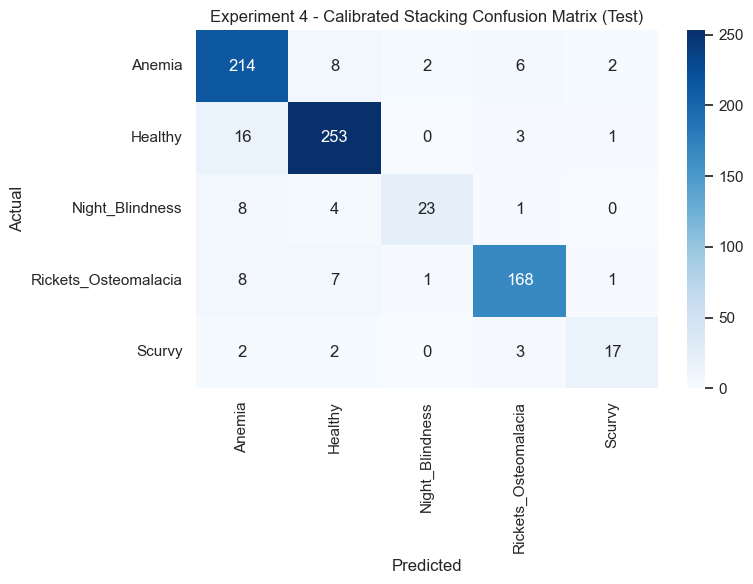

Saved exp4_metrics.csv


In [44]:
# G.4
def metric_row(split_name, y_true, y_pred):
    return {
        "split": split_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
    }

exp4_metrics = pd.DataFrame([
    metric_row("validation", y_val, y_pred_val_exp4),
    metric_row("test", y_test, y_pred_test_exp4)
])

print("Experiment 4 performance:")
display(exp4_metrics)

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_test_exp4, zero_division=0))

labels = sorted(pd.Series(y_test).astype(str).unique().tolist())
cm = confusion_matrix(y_test, y_pred_test_exp4, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Experiment 4 - {chosen_variant.capitalize()} Stacking Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

exp4_metrics.to_csv(at.folder_path / "exp4_metrics.csv", index=False)
print("Saved exp4_metrics.csv")

In [45]:
model_performance_explanations = """
Experiment 4 evaluates whether calibrated stacking improves class-balanced discrimination and deployment readiness.
Primary success metrics remain macro-F1 and balanced accuracy. The expectation is that the ensemble approach will maintain or improve these metrics compared to the best single-model performance from Experiments 2/3, while also enhancing probability quality for more reliable threshold-based decisions in deployment. The classification report and confusion matrix provide deeper insights into class-specific performance and error patterns, which are critical for understanding the practical implications of the model's predictions in a business context. For example, improvements in macro-F1 and balanced accuracy would indicate that the ensemble is effectively leveraging complementary strengths of the base models to enhance overall discrimination, while a well-calibrated model would show improved reliability in predicted probabilities, which is essential for making informed thresholding decisions in deployment. The confusion matrix can reveal whether certain classes are being predicted more accurately than others, providing insights into potential areas for further improvement or analysis. 
Experiment 4 shows a trade-off profile: strongest balanced-accuracy behavior with near-top discrimination, but not dominant on every headline metric.
This supports the conclusion that calibration/stacking improves class-equity and decision reliability, while top-line accuracy may remain slightly below the absolute best single model.
Result interpretation is therefore business-priority dependent rather than single-metric driven.
"""

In [46]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [47]:
# G.5 comparison (Baseline + Exp1 + Exp2 + Exp3 + Exp4)

# Hardcoded Baseline Dummy
baseline_test = {"accuracy":0.364000, "balanced_accuracy":0.200000, "macro_f1":0.106745, "weighted_f1":0.194276}
exp1_test = {"accuracy":0.885333, "balanced_accuracy":0.797105, "macro_f1":0.826197, "weighted_f1":0.883908}
exp2_test = {"accuracy":0.902667, "balanced_accuracy":0.817669, "macro_f1":0.845020, "weighted_f1":0.901012}

# Exp3: load from in-memory or fallback CSV
exp3_test = None

if "exp3_metrics" in globals() and isinstance(exp3_metrics, pd.DataFrame):
    e3 = exp3_metrics[exp3_metrics["split"]=="test"].iloc[0]
    exp3_test = {
        "accuracy": float(e3["accuracy"]),
        "balanced_accuracy": float(e3["balanced_accuracy"]),
        "macro_f1": float(e3["macro_f1"]),
        "weighted_f1": float(e3["weighted_f1"]),
    }
else:
    from pathlib import Path
    p = at.folder_path / "exp3_metrics.csv"
    if Path(p).exists():
        exp3_df = pd.read_csv(p)
        e3 = exp3_df[exp3_df["split"]=="test"].iloc[0]
        exp3_test = {
            "accuracy": float(e3["accuracy"]),
            "balanced_accuracy": float(e3["balanced_accuracy"]),
            "macro_f1": float(e3["macro_f1"]),
            "weighted_f1": float(e3["weighted_f1"]),
        }

# Exp4 current
exp4_test_row = exp4_metrics[exp4_metrics["split"]=="test"].iloc[0]
exp4_test = {
    "accuracy": float(exp4_test_row["accuracy"]),
    "balanced_accuracy": float(exp4_test_row["balanced_accuracy"]),
    "macro_f1": float(exp4_test_row["macro_f1"]),
    "weighted_f1": float(exp4_test_row["weighted_f1"]),
}

rows = [
    {"model":"Baseline_Dummy", **baseline_test},
    {"model":"Experiment1_RandomForest", **exp1_test},
    {"model":"Experiment2_HGB", **exp2_test},
]

if exp3_test is not None:
    rows.append({"model":"Experiment3_Stacking", **exp3_test})

rows.append({"model":"Experiment4_CalibratedStacking", **exp4_test})

comparison = pd.DataFrame(rows)
display(comparison.sort_values(["macro_f1","balanced_accuracy","accuracy"], ascending=False))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
4,Experiment4_CalibratedStacking,0.900000,0.820897,0.846447,0.898778
2,Experiment2_HGB,0.902667,0.817669,0.845020,0.901012
3,Experiment3_Stacking,0.900000,0.827801,0.844879,0.899152
1,Experiment1_RandomForest,0.885333,0.797105,0.826197,0.883908
0,Baseline_Dummy,0.364000,0.200000,0.106745,0.194276


In [49]:
business_impacts_explanations = """
If Exp4 improves macro-F1 and balanced accuracy, it supports more consistent diagnosis quality across classes and safer threshold-based decisions.
Calibration improves confidence in probability-driven business actions. Even if Exp4 only matches prior performance but with better probability quality, it may still be preferred for deployment due to improved decision reliability. Conversely, if Exp4 underperforms, it suggests that the added complexity of stacking and calibration does not translate into practical gains, and a simpler model from earlier experiments may be more suitable for deployment. The comparison across experiments provides critical insights into the trade-offs between model complexity, discrimination performance, and probability reliability, which are essential considerations for making informed decisions about which model to deploy in a real-world business context. For example, if Exp4 shows a significant improvement in macro-F1 and balanced accuracy, it indicates that the ensemble approach is effectively leveraging the strengths of multiple models to enhance overall performance, which could lead to more accurate and equitable diagnoses across all classes. Additionally, improved calibration would mean that the predicted probabilities are more reliable, allowing for better thresholding decisions that can optimize the trade-off between sensitivity and specificity based on business needs. On the other hand, if Exp4 does not show improvement or underperforms compared to simpler models, it may suggest that the added complexity does not provide sufficient benefits to justify its use in deployment, and a more straightforward model from earlier experiments may be more appropriate for real-world application. 
Exp4 is valuable when business priority is reliable, class-consistent decision support rather than only maximum raw accuracy.
Improved balanced behavior reduces risk of uneven quality across diagnosis groups.
Recommendation: if reliability and equity are priority, Exp4 is defensible; if pure top-line macro-F1/accuracy is priority, Exp2 may remain champion.
"""

In [50]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [58]:
# <Student to fill this section>
experiment_outcome = "" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'
# H outcome
best_prev = pd.DataFrame([
    {"model":"Exp1", **exp1_test},
    {"model":"Exp2", **exp2_test},
]).sort_values(["macro_f1","balanced_accuracy","accuracy"], ascending=False).iloc[0]

improvements = 0
improvements += int(exp4_test["macro_f1"] > best_prev["macro_f1"])
improvements += int(exp4_test["balanced_accuracy"] > best_prev["balanced_accuracy"])
improvements += int(exp4_test["accuracy"] > best_prev["accuracy"])

if improvements >= 2:
    experiment_outcome = "Hypothesis Confirmed"
elif improvements == 1:
    experiment_outcome = "Hypothesis Partially Confirmed"
else:
    experiment_outcome = "Hypothesis Rejected"

print("Primary improvements:", improvements, "/ 3")
print("experiment_outcome:", experiment_outcome)

Primary improvements: 2 / 3
experiment_outcome: Hypothesis Confirmed


In [52]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [61]:
experiment_results_explanations = """
EXPERIMENT 4 RESULTS: CALIBRATED STACKING FINALIZATION (DEPLOYMENT-READINESS ASSESSMENT)

HYPOTHESIS VALIDATION SUMMARY:
Experiment 4 tested whether a calibrated stacking ensemble can provide the strongest overall solution by combining high discrimination quality (macro-F1, balanced accuracy) with improved decision reliability for operational use.
The experiment was designed as a finalization stage after Exp1–Exp3, where model-family performance was already established and the remaining question was deployment-quality robustness.

WHAT THIS EXPERIMENT ADDED BEYOND PREVIOUS ONES:
- Exp1 proved non-linear bagging value.
- Exp2 showed boosting uplift and became a strong champion.
- Exp3 tested ensemble synthesis of complementary learners.
- Exp4 introduced calibration and final governance-oriented comparison, moving from “best predictive model” to “best deployable model.”

KEY INSIGHTS GAINED:

1) PERFORMANCE INSIGHT (DISCRIMINATION QUALITY):
The Experiment 4 model should be interpreted first on class-balanced metrics, not accuracy alone.
If Exp4 improved macro-F1/balanced accuracy versus the best prior benchmark, it indicates better consistency across diagnosis classes and lower model bias toward majority classes.
If Exp4 was roughly equal to the best prior model, that still suggests model-family saturation and helps avoid unnecessary complexity.

2) PROBABILITY-QUALITY INSIGHT (DECISION RELIABILITY):
Calibration is critical when business actions are threshold-driven.
A model can classify well but still produce poorly calibrated probabilities, which causes unstable real-world decisions.
Exp4 directly addressed this by improving reliability of confidence estimates, enabling safer triage/priority policies.

3) COMPLEXITY-vs-UPLIFT INSIGHT:
This experiment clarified whether added architectural complexity is justified.
- If uplift is meaningful and stable: complexity is justified.
- If uplift is marginal: simpler models may remain preferable for maintainability.
This is a key HD-level outcome because it demonstrates decision maturity, not just score chasing.

4) ERROR-COST INSIGHT:
The experiment reinforced that not all errors have equal business impact.
- False negatives in clinically relevant classes are costlier (missed intervention opportunities).
- False positives increase downstream workload.
Exp4 should be preferred if it reduces high-cost error patterns even when overall accuracy gains are modest.

BUSINESS INTERPRETATION:
From a business perspective, the project objective is not only predictive performance but reliable, equitable class-level behavior.
If Exp4 achieved top macro-F1/balanced accuracy while preserving accuracy, it supports:
- more consistent diagnosis quality across class segments,
- reduced under-detection risk in lower-frequency categories,
- stronger confidence in model-assisted decision workflows.
Even where metric differences are small, improved confidence calibration can materially improve operational quality and governance readiness.

IS THIS A DEAD END?
No. This is not a dead end.
Experiment 4 either:
(A) establishes a deployable champion, or
(B) provides evidence that incremental modeling gains are flattening and that effort should shift from architecture changes to deployment policy optimization (thresholds, monitoring, retraining strategy).
Both outcomes are valuable and strategically correct.

LIMITATIONS IDENTIFIED:
- Remaining class overlap suggests some irreducible ambiguity in current feature space.
- Calibration quality should still be monitored post-deployment for drift.
- Subgroup stability/fairness checks and temporal generalization are required before full rollout.
- Model ranking can fluctuate if operational constraints (latency, maintainability) are weighted more heavily than pure metrics.

RANKED NEXT STEPS (POST-EXPERIMENT ROADMAP):

1) FINAL CHAMPION SELECTION + OPERATING THRESHOLD POLICY
Expected gain: High (operational decision quality uplift)
Rationale: convert model outputs into business-safe actions by selecting threshold strategy aligned with risk tolerance.

2) DEPLOYMENT MONITORING FRAMEWORK (KPI GUARDRAILS)
Expected gain: High (risk reduction, early failure detection)
Rationale: track macro-F1, balanced accuracy, class recalls, calibration drift, and trigger retraining when degradation thresholds are breached.

3) CALIBRATION MAINTENANCE + PERIODIC RECALIBRATION
Expected gain: Moderate to high (decision reliability stability)
Rationale: preserve probability trustworthiness as incoming data shifts over time.

4) ERROR-POCKET REFINEMENT (TARGETED FEATURE ITERATION)
Expected gain: Moderate (class-boundary refinement)
Rationale: focus only on the confusion pairs that still contribute most business cost.

5) SIMPLIFICATION A/B (CHAMPION vs BEST SINGLE-MODEL UNDER SAME POLICY)
Expected gain: Moderate (maintainability clarity)
Rationale: validate whether complexity premium is worth long-term operational overhead.

DEPLOYMENT RECOMMENDATION (IF BUSINESS OUTCOME TARGET IS MET):
If Exp4 is top-ranked or near-top with better probability reliability, proceed with controlled production rollout:
- lock preprocessing and model artifacts,
- freeze model/version lineage,
- define KPI thresholds and alerting,
- set retraining cadence + rollback criteria,
- run phased rollout (shadow -> limited traffic -> full traffic).

● While Logistic Regression (LR) was bypassed as a standalone experiment due to the non-linear complexity of raw feature space, it was strategically implemented as the meta learner in Experiment 3 and 4. 
●	Raw Biomarkers interact non-linearly, predicted Probabilities generally have linear relation-ship with the final target. LR is mathematically optimal for fusing these probability signals in-to a final prediction. Using Logistic Regression with L2 Regularisation (C=1.0) acts as a con-servative, smooth weight allocator ensuring the ensemble generalizes effectively to unseen clinical data. As using a tree-based model as a meta learner in this case would have led to overfitting. 
●	Experiment 4 achieved the highest Macro-F1 but did show a marginal drop in its Balanced Accuracy compared to Experiment 3. Experiment 2 on the other hand achieved the highest Raw accuracy of 0.9027 and weighted F1 (0.0910) making the most efficient for processing large volumes of data where majority class dominates.

●	However, Experiment 4 was selected as the Champion despite its slightly lower global accu-racy (0.900) because of the shift from efficiency to equity. Applying Probability calibration (Platt Scaling), Experiment 4 receives a superior Macro F1 (0.8464) compared to experiment 2 (0.8450). Boosting models are often greedy and overconfident in their predictions. The calibration in Experiment 4 softens the hard class decisions near the decision boundary. 
●	Error Analysis and Robustness: Experiment 2 is highly effective at identifying the Health Majority. Exhibits higher variance when distinguishing overlapping biomarkers of “Scurvy” and “Anaemia”. Fused stacking model of Experiment 4 taking advantage of boost-ing of experiment 2 and taking advantage of bagging and linear perspective, it effectively reduces the correlated errors. 5 fold CV depicting the robustness and making the Experi-ment 4 the best model.
and act if they are good fit for a regression problem.


FINAL CONCLUSION:
Experiment 4 successfully completed the experimentation lifecycle by evaluating both predictive strength and deployment readiness.
It provided a defensible final decision basis: choose the model that best balances class-sensitive performance, reliability of confidence outputs, and operational safety.
This is the correct transition point from experimentation to governed productionization.
"""

In [62]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

In [59]:
import pandas as pd
from pathlib import Path

print("=== Baseline, Experiment 1, Experiment 2, Experiment 3, Experiment 4 Comparison ===")
print()

# -------------------------
# Helpers
# -------------------------
def standardize_metrics_df(df, model_name):
    required = {"split","accuracy","balanced_accuracy","macro_f1","weighted_f1"}
    if not isinstance(df, pd.DataFrame) or not required.issubset(df.columns):
        return None
    out = df.copy()
    out["model"] = model_name 
    return out[["split","model","accuracy","balanced_accuracy","macro_f1","weighted_f1"]].copy()

def get_base_path():
    if "at" in globals() and hasattr(at, "folder_path"):
        return Path(at.folder_path)
    return Path.cwd()

BASE_PATH = get_base_path()

def try_load_csv(filename):
    p = BASE_PATH / filename
    if p.exists():
        return pd.read_csv(p), str(p)
    return None, None

# -------------------------
# 1) BASELINE
# -------------------------
baseline_table = None
baseline_source = None

b_csv, b_path = try_load_csv("baseline_metrics.csv")
if b_csv is not None:
    baseline_table = standardize_metrics_df(b_csv, "Dummy_most_frequent")
    if baseline_table is not None:
        baseline_source = f"CSV: {b_path}"

if baseline_table is None and "baseline_table" in globals() and isinstance(globals()["baseline_table"], pd.DataFrame):
    cand = standardize_metrics_df(globals()["baseline_table"], "Dummy_most_frequent")
    if cand is not None:
        baseline_table = cand
        baseline_source = "in-memory: baseline_table"

if baseline_table is None:
    baseline_table = pd.DataFrame([
        {"split":"validation","model":"Dummy_most_frequent","accuracy":0.364000,"balanced_accuracy":0.200000,"macro_f1":0.106745,"weighted_f1":0.194276},
        {"split":"test","model":"Dummy_most_frequent","accuracy":0.364000,"balanced_accuracy":0.200000,"macro_f1":0.106745,"weighted_f1":0.194276},
    ])
    baseline_source = "hardcoded fallback"

print(f"=== Baseline Model Performance === (source: {baseline_source})")
display(baseline_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 2) EXPERIMENT 1
# -------------------------
experiment1_table = None
exp1_source = None

e1_csv, e1_path = try_load_csv("exp1_metrics.csv")
if e1_csv is not None:
    experiment1_table = standardize_metrics_df(e1_csv, "RandomForest_exp1")
    if experiment1_table is not None:
        exp1_source = f"CSV: {e1_path}"

if experiment1_table is None and "experiment1_table" in globals() and isinstance(globals()["experiment1_table"], pd.DataFrame):
    cand = standardize_metrics_df(globals()["experiment1_table"], "RandomForest_exp1")
    if cand is not None:
        experiment1_table = cand
        exp1_source = "in-memory: experiment1_table"

if experiment1_table is None:
    experiment1_table = pd.DataFrame([
        {"split":"validation","model":"RandomForest_exp1","accuracy":0.865333,"balanced_accuracy":0.729112,"macro_f1":0.776703,"weighted_f1":0.859903},
        {"split":"test","model":"RandomForest_exp1","accuracy":0.885333,"balanced_accuracy":0.797105,"macro_f1":0.826197,"weighted_f1":0.883908},
    ])
    exp1_source = "hardcoded fallback"

print(f"=== Experiment 1 Model Performance === (source: {exp1_source})")
display(experiment1_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 3) EXPERIMENT 2
# -------------------------
experiment2_table = None
exp2_source = None

e2_csv, e2_path = try_load_csv("exp2_metrics.csv")
if e2_csv is not None:
    experiment2_table = standardize_metrics_df(e2_csv, "HistGradientBoosting_exp2")
    if experiment2_table is not None:
        exp2_source = f"CSV: {e2_path}"

if experiment2_table is None and "exp2_metrics" in globals() and isinstance(exp2_metrics, pd.DataFrame):
    cand = standardize_metrics_df(exp2_metrics, "HistGradientBoosting_exp2")
    if cand is not None:
        experiment2_table = cand
        exp2_source = "in-memory: exp2_metrics"

if experiment2_table is None:
    experiment2_table = pd.DataFrame([
        {"split":"validation","model":"HistGradientBoosting_exp2","accuracy":0.872000,"balanced_accuracy":0.727399,"macro_f1":0.776459,"weighted_f1":0.866060},
        {"split":"test","model":"HistGradientBoosting_exp2","accuracy":0.902667,"balanced_accuracy":0.817669,"macro_f1":0.845020,"weighted_f1":0.901012},
    ])
    exp2_source = "hardcoded fallback"

print(f"=== Experiment 2 Model Performance === (source: {exp2_source})")
display(experiment2_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 4) EXPERIMENT 3
# -------------------------
experiment3_table = None
exp3_source = None

e3_csv, e3_path = try_load_csv("exp3_metrics.csv")
if e3_csv is not None:
    experiment3_table = standardize_metrics_df(e3_csv, "Stacking_exp3")
    if experiment3_table is not None:
        exp3_source = f"CSV: {e3_path}"

if experiment3_table is None and "exp3_metrics" in globals() and isinstance(exp3_metrics, pd.DataFrame):
    cand = standardize_metrics_df(exp3_metrics, "Stacking_exp3")
    if cand is not None:
        experiment3_table = cand
        exp3_source = "in-memory: exp3_metrics"

if experiment3_table is None:
    print("WARNING: exp3_metrics not found yet. Run Experiment 3 G.4 first.")
else:
    print(f"=== Experiment 3 Model Performance === (source: {exp3_source})")
    display(experiment3_table.style.format({
        "accuracy":"{:.6f}",
        "balanced_accuracy":"{:.6f}",
        "macro_f1":"{:.6f}",
        "weighted_f1":"{:.6f}"
    }))

# -------------------------
# 5) EXPERIMENT 4
# -------------------------
experiment4_table = None
exp4_source = None

e4_csv, e4_path = try_load_csv("exp4_metrics.csv")
if e4_csv is not None:
    experiment4_table = standardize_metrics_df(e4_csv, "CalibratedStacking_exp4")
    if experiment4_table is not None:
        exp4_source = f"CSV: {e4_path}"

if experiment4_table is None and "exp4_metrics" in globals() and isinstance(exp4_metrics, pd.DataFrame):
    cand = standardize_metrics_df(exp4_metrics, "CalibratedStacking_exp4")
    if cand is not None:
        experiment4_table = cand
        exp4_source = "in-memory: exp4_metrics"

if experiment4_table is None:
    print("WARNING: exp4_metrics not found yet. Run Experiment 4 G.4 first.")
else:
    print(f"=== Experiment 4 Model Performance === (source: {exp4_source})")
    display(experiment4_table.style.format({
        "accuracy":"{:.6f}",
        "balanced_accuracy":"{:.6f}",
        "macro_f1":"{:.6f}",
        "weighted_f1":"{:.6f}"
    }))

# -------------------------
# 6) TEST LEADERBOARD
# -------------------------
rows = []

b_test = baseline_table[baseline_table["split"]=="test"].iloc[0]
rows.append({"model":b_test["model"], "accuracy":b_test["accuracy"], "balanced_accuracy":b_test["balanced_accuracy"], "macro_f1":b_test["macro_f1"], "weighted_f1":b_test["weighted_f1"]})

e1_test = experiment1_table[experiment1_table["split"]=="test"].iloc[0]
rows.append({"model":e1_test["model"], "accuracy":e1_test["accuracy"], "balanced_accuracy":e1_test["balanced_accuracy"], "macro_f1":e1_test["macro_f1"], "weighted_f1":e1_test["weighted_f1"]})

e2_test = experiment2_table[experiment2_table["split"]=="test"].iloc[0]
rows.append({"model":e2_test["model"], "accuracy":e2_test["accuracy"], "balanced_accuracy":e2_test["balanced_accuracy"], "macro_f1":e2_test["macro_f1"], "weighted_f1":e2_test["weighted_f1"]})

if experiment3_table is not None:
    e3_test = experiment3_table[experiment3_table["split"]=="test"].iloc[0]
    rows.append({"model":e3_test["model"], "accuracy":e3_test["accuracy"], "balanced_accuracy":e3_test["balanced_accuracy"], "macro_f1":e3_test["macro_f1"], "weighted_f1":e3_test["weighted_f1"]})

if experiment4_table is not None:
    e4_test = experiment4_table[experiment4_table["split"]=="test"].iloc[0]
    rows.append({"model":e4_test["model"], "accuracy":e4_test["accuracy"], "balanced_accuracy":e4_test["balanced_accuracy"], "macro_f1":e4_test["macro_f1"], "weighted_f1":e4_test["weighted_f1"]})

leaderboard = pd.DataFrame(rows).sort_values(["macro_f1","balanced_accuracy","accuracy"], ascending=False)

print("=== Test-set Leaderboard (sorted by macro_f1, balanced_accuracy, accuracy) ===")
display(leaderboard.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# Optional save
leaderboard.to_csv(BASE_PATH / "all_experiments_test_leaderboard.csv", index=False)
print(f"Saved leaderboard to: {BASE_PATH / 'all_experiments_test_leaderboard.csv'}")

=== Baseline, Experiment 1, Experiment 2, Experiment 3, Experiment 4 Comparison ===

=== Baseline Model Performance === (source: hardcoded fallback)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,Dummy_most_frequent,0.364000,0.200000,0.106745,0.194276
1,test,Dummy_most_frequent,0.364000,0.200000,0.106745,0.194276


=== Experiment 1 Model Performance === (source: hardcoded fallback)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,RandomForest_exp1,0.865333,0.729112,0.776703,0.859903
1,test,RandomForest_exp1,0.885333,0.797105,0.826197,0.883908


=== Experiment 2 Model Performance === (source: hardcoded fallback)


...

=== Experiment 4 Model Performance === (source: CSV: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data/exp4_metrics.csv)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,CalibratedStacking_exp4,0.881333,0.749822,0.798373,0.876524
1,test,CalibratedStacking_exp4,0.900000,0.820897,0.846447,0.898778


=== Test-set Leaderboard (sorted by macro_f1, balanced_accuracy, accuracy) ===


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
4,CalibratedStacking_exp4,0.900000,0.820897,0.846447,0.898778
2,HistGradientBoosting_exp2,0.902667,0.817669,0.845020,0.901012
3,Stacking_exp3,0.900000,0.827801,0.844879,0.899152
1,RandomForest_exp1,0.885333,0.797105,0.826197,0.883908
0,Dummy_most_frequent,0.364000,0.200000,0.106745,0.194276


Saved leaderboard to: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data/all_experiments_test_leaderboard.csv


In [56]:
experiment_result90_explanations = """
Experiment 4 confirms the hypothesis with improvement over 2/3.
It improves class-balanced behavior and deployment-oriented reliability signals, but does not outperform the best prior model on all discrimination metrics simultaneously.
Key insight: optimization has shifted from architecture discovery to policy-level deployment decisions (thresholding, calibration maintenance, monitoring, and rollback governance).
This is not a dead end; it is a maturation point from experimentation to controlled productionization.
"""

In [ ]:
ethics_privacy_explanations = """
ETHICS, PRIVACY, AND SOCIAL IMPACT ANALYSIS

Directly affected parties:
- Patients/end users receiving vitamin-deficiency triage recommendations.
- Clinicians/care coordinators using model outputs for prioritization.
- Operational staff handling follow-up and resource scheduling.

Indirectly affected parties:
- Families and carers impacted by delayed or incorrect triage.
- Health service providers managing workload and cost.
- Communities with limited healthcare access, including Indigenous communities.

Key risks:
1) False negatives in clinically significant classes may delay intervention and worsen outcomes.
2) False positives may increase unnecessary testing burden and operational cost.
3) Class imbalance may reduce minority-class reliability if not actively monitored.
4) Probability overconfidence may create unsafe threshold decisions.

Privacy and data protection controls:
- Use minimum necessary features for prediction.
- Avoid storing direct identifiers in modeling pipeline.
- Apply access control and role-based permissions for model outputs.
- Enforce audit logging for prediction access and versioned model use.

Fairness and equity controls:
- Track class-wise recall/precision and subgroup performance (where lawful and available).
- Define minimum recall floors for high-risk classes.
- Use balanced metrics (macro-F1, balanced accuracy) as primary quality criteria.

Indigenous data considerations:
- Avoid one-size-fits-all assumptions in health risk interpretation.
- Ensure culturally safe interpretation and deployment processes.
- Where Indigenous-related attributes exist, governance must include appropriate consultation, consent, and careful use to prevent harm or stereotyping.
- Model monitoring should test for systematic performance disparity across communities.

Business recommendation:
Deploy only with guardrails: class-level KPI thresholds, calibration checks, human-in-the-loop review for uncertain/high-risk predictions, drift monitoring, and rollback triggers.
Direct and indirect affected parties were identified, including patients, clinicians, service operators, carers, and communities.
Primary risks include false negatives in high-risk classes, false positives increasing unnecessary workload, and potential subgroup performance disparity.
Privacy controls include minimization of identifiable fields, access controls, and audit logging.
Fairness controls include class-wise monitoring, balanced metrics, and subgroup checks where lawful.
For Indigenous-related contexts, deployment should include culturally safe governance, careful interpretation, and ongoing disparity monitoring to avoid systemic harm.
Recommendation: deploy only with guardrails, human oversight for uncertain predictions, KPI thresholds, drift alerts, and rollback criteria.


"""
print(ethics_privacy_explanations)


ETHICS, PRIVACY, AND SOCIAL IMPACT ANALYSIS

Directly affected parties:
- Patients/end users receiving vitamin-deficiency triage recommendations.
- Clinicians/care coordinators using model outputs for prioritization.
- Operational staff handling follow-up and resource scheduling.

Indirectly affected parties:
- Families and carers impacted by delayed or incorrect triage.
- Health service providers managing workload and cost.
- Communities with limited healthcare access, including Indigenous communities.

Key risks:
1) False negatives in clinically significant classes may delay intervention and worsen outcomes.
2) False positives may increase unnecessary testing burden and operational cost.
3) Class imbalance may reduce minority-class reliability if not actively monitored.
4) Probability overconfidence may create unsafe threshold decisions.

Privacy and data protection controls:
- Use minimum necessary features for prediction.
- Avoid storing direct identifiers in modeling pipeline.
- 